# 😊 Facial Expression Recognition (FER) - Training Notebook
This notebook trains a CNN model using the FER dataset CSV file.

**CSV format expected:**
- `emotion` — integer label (0–6)
- `pixels` — space-separated pixel values (48x48 = 2304 values)
- `Usage` — `Training`, `PublicTest`, or `PrivateTest`

**Emotion labels:**
0=Angry, 1=Disgust, 2=Fear, 3=Happy, 4=Sad, 5=Surprise, 6=Neutral

## 1. Install & Import Libraries

In [1]:
# Install required libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

from sklearn.metrics import classification_report, confusion_matrix

print('TensorFlow version:', tf.__version__)
print('GPU available:', tf.config.list_physical_devices('GPU'))

2026-03-04 18:48:28.271461: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-04 18:48:29.080158: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-04 18:48:52.259584: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Upload & Load the CSV

In [ ]:
# Upload your CSV file (e.g., fer2013.csv)
# uploaded = files.upload()
# csv_filename = list(uploaded.keys())[0]
# print(f'Loaded file: {csv_filename}')

df = pd.read_csv('../fer2013.csv')
print('Shape:', df.shape)
df.head()

## 3. Explore & Visualize the Data

In [ ]:
EMOTION_LABELS = ['Angry', 'Disgust', 'Fear', 'Happy', 'Sad', 'Surprise', 'Neutral']

# Class distribution
plt.figure(figsize=(10, 4))
df['emotion'].value_counts().sort_index().plot(kind='bar', color='steelblue')
plt.xticks(range(7), EMOTION_LABELS, rotation=45)
plt.title('Emotion Class Distribution')
plt.xlabel('Emotion')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

print('Usage split:')
print(df['Usage'].value_counts())

In [ ]:
# Preview some sample images
fig, axes = plt.subplots(2, 7, figsize=(14, 5))
for emotion_id in range(7):
    samples = df[df['emotion'] == emotion_id].head(2)
    for row, (_, sample) in enumerate(samples.iterrows()):
        pixels = np.array(sample['pixels'].split(), dtype=np.uint8).reshape(48, 48)
        axes[row, emotion_id].imshow(pixels, cmap='gray')
        axes[row, emotion_id].axis('off')
        if row == 0:
            axes[row, emotion_id].set_title(EMOTION_LABELS[emotion_id], fontsize=9)
plt.suptitle('Sample Images per Emotion', fontsize=12)
plt.tight_layout()
plt.show()

## 4. Preprocess the Data

In [3]:
# IMG_SIZE = 48
# NUM_CLASSES = 7

# def parse_pixels(df):
#     """Convert pixel strings to numpy arrays."""
#     X = np.array([row.split() for row in df['pixels']], dtype=np.float32)
#     X = X.reshape(-1, IMG_SIZE, IMG_SIZE, 1) / 255.0  # Normalize to [0, 1]
#     y = keras.utils.to_categorical(df['emotion'].values, NUM_CLASSES)
#     return X, y

# train_df = df[df['Usage'] == 'Training']
# val_df   = df[df['Usage'] == 'PublicTest']
# test_df  = df[df['Usage'] == 'PrivateTest']

# X_train, y_train = parse_pixels(train_df)
# X_val,   y_val   = parse_pixels(val_df)
# X_test,  y_test  = parse_pixels(test_df)

# print(f'Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}')

import os
import cv2
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

# Define paths and labels
CSV_PATH = '../fer2013.csv'
DATASET_PATH = '../dataset'
EMOTION_LABELS = ['Angry', 'Disgust', 'Fear', 'Happy', 'Sad', 'Surprise', 'Neutral']
IMG_SIZE = 48
NUM_CLASSES = 7

def load_images_from_folders(dataset_path, emotion_labels, max_images_per_emotion=500):
    """Load images from train and test folders with limit."""
    X_data, y_data = [], []
    
    # Load training images
    train_path = os.path.join(dataset_path, 'train')
    for emotion_id, emotion in enumerate(emotion_labels):
        emotion_path = os.path.join(train_path, emotion.lower())
        count = 0
        if os.path.exists(emotion_path):
            for img_file in os.listdir(emotion_path):
                if count >= max_images_per_emotion:
                    break
                img = cv2.imread(os.path.join(emotion_path, img_file), cv2.IMREAD_GRAYSCALE)
                if img is not None:
                    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
                    X_data.append(img)
                    y_data.append(emotion_id)
                    count += 1
    
    # Load test images
    test_path = os.path.join(dataset_path, 'test')
    for emotion_id, emotion in enumerate(emotion_labels):
        emotion_path = os.path.join(test_path, emotion.lower())
        count = 0
        if os.path.exists(emotion_path):
            for img_file in os.listdir(emotion_path):
                if count >= max_images_per_emotion:
                    break
                img = cv2.imread(os.path.join(emotion_path, img_file), cv2.IMREAD_GRAYSCALE)
                if img is not None:
                    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
                    X_data.append(img)
                    y_data.append(emotion_id)
                    count += 1
    
    X_data = np.array(X_data, dtype=np.float32).reshape(-1, IMG_SIZE, IMG_SIZE, 1) / 255.0
    y_data = np.array(y_data)
    
    return X_data, y_data

def parse_csv(csv_path, max_samples=5000):
    """Load images from CSV file with limit."""
    df = pd.read_csv(csv_path)
    df = df.head(max_samples)  # Limit to first 5000 rows
    X_csv = np.array([row.split() for row in df['pixels']], dtype=np.float32)
    X_csv = X_csv.reshape(-1, IMG_SIZE, IMG_SIZE, 1) / 255.0
    y_csv = df['emotion'].values
    
    return X_csv, y_csv

# Load data from CSV
print('Loading data from CSV...')
X_csv, y_csv = parse_csv(CSV_PATH, max_samples=5000)
print(f'CSV loaded: {X_csv.shape}')

# Load data from folders
print('Loading data from folders...')
X_folders, y_folders = load_images_from_folders(DATASET_PATH, EMOTION_LABELS, max_images_per_emotion=300)
print(f'Folders loaded: {X_folders.shape}')

# Combine both datasets
X_combined = np.concatenate([X_csv, X_folders], axis=0)
y_combined = np.concatenate([y_csv, y_folders], axis=0)

print(f'Combined data: {X_combined.shape}')

# Split into train, validation, and test (80-10-10)
X_train, X_temp, y_train, y_temp = train_test_split(X_combined, y_combined, test_size=0.2, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# Convert labels to one-hot encoding
y_train = keras.utils.to_categorical(y_train, NUM_CLASSES)
y_val = keras.utils.to_categorical(y_val, NUM_CLASSES)
y_test = keras.utils.to_categorical(y_test, NUM_CLASSES)

print(f'Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}')

Loading data from CSV...
CSV loaded: (5000, 48, 48, 1)
Loading data from folders...
Folders loaded: (4011, 48, 48, 1)
Combined data: (9011, 48, 48, 1)
Train: (7208, 48, 48, 1), Val: (901, 48, 48, 1), Test: (902, 48, 48, 1)


## 5. Data Augmentation

In [4]:
# Data augmentation pipeline
data_augmentation = keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomTranslation(0.05, 0.05),
], name='augmentation')

# Create tf.data datasets for efficient training
BATCH_SIZE = 64
AUTOTUNE = tf.data.AUTOTUNE

train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train))
train_ds = train_ds.shuffle(10000).batch(BATCH_SIZE).map(
    lambda x, y: (data_augmentation(x, training=True), y),
    num_parallel_calls=AUTOTUNE
).prefetch(AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val)).batch(BATCH_SIZE).prefetch(AUTOTUNE)
test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test)).batch(BATCH_SIZE).prefetch(AUTOTUNE)

print('Datasets ready!')

I0000 00:00:1772626222.567683    6363 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3536 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


Datasets ready!


## 6. Build the CNN Model

In [5]:
def build_model(input_shape=(48, 48, 1), num_classes=7):
    inputs = keras.Input(shape=input_shape)

    # Block 1
    x = layers.Conv2D(64, 3, padding='same', activation='relu')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Dropout(0.25)(x)

    # Block 2
    x = layers.Conv2D(128, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(128, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Dropout(0.25)(x)

    # Block 3
    x = layers.Conv2D(256, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(256, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Dropout(0.25)(x)

    # Classifier head
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(512, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    return keras.Model(inputs, outputs, name='FER_CNN')

model = build_model()
model.summary()

Model: "FER_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 48, 48, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 48, 48, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 48, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,414,599 (5.40 MB)

 Trainable params: 1,411,783 (5.39 MB)

 Non-trainable params: 2,816 (11.00 KB)

## 7. Compile & Train the Model

In [6]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Callbacks
callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1),
    ModelCheckpoint('best_fer_model.keras', monitor='val_accuracy', save_best_only=True, verbose=1)
]

EPOCHS = 60

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/60


2026-03-04 19:10:43.548770: I external/local_xla/xla/service/service.cc:163] XLA service 0x7b6b30003000 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-03-04 19:10:43.548813: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 4050 Laptop GPU, Compute Capability 8.9
2026-03-04 19:10:43.729818: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-03-04 19:10:44.588989: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91900
2026-03-04 19:10:45.173289: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-04 19:10:45.

  1/113 ━━━━━━━━━━━━━━━━━━━━ 31:18 17s/step - accuracy: 0.2188 - loss: 2.5704

I0000 00:00:1772626256.532108    6678 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


112/113 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.1741 - loss: 2.5794

2026-03-04 19:11:01.035803: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-04 19:11:01.035875: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-04 19:11:01.410528: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_3740', 4 bytes spill stores, 4 bytes spill loads

2026-03-04 19:11:02.505149: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : R

113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step - accuracy: 0.1741 - loss: 2.5785
Epoch 1: val_accuracy improved from None to 0.19645, saving model to best_fer_model.keras

Epoch 1: finished saving model to best_fer_model.keras
113/113 ━━━━━━━━━━━━━━━━━━━━ 35s 161ms/step - accuracy: 0.1744 - loss: 2.4740 - val_accuracy: 0.1964 - val_loss: 2.2557 - learning_rate: 0.0010
Epoch 2/60
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.1946 - loss: 2.2494
Epoch 2: val_accuracy did not improve from 0.19645
113/113 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - accuracy: 0.1894 - loss: 2.2048 - val_accuracy: 0.1654 - val_loss: 1.9477 - learning_rate: 0.0010
Epoch 3/60
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.1939 - loss: 2.1035
Epoch 3: val_accuracy did not improve from 0.19645
113/113 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - accuracy: 0.1845 - loss: 2.0919 - val_accuracy: 0.1287 - val_loss: 1.9721 - learning_rate: 0.0010
Epoch 4/60
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.1938 -

## 8. Plot Training History

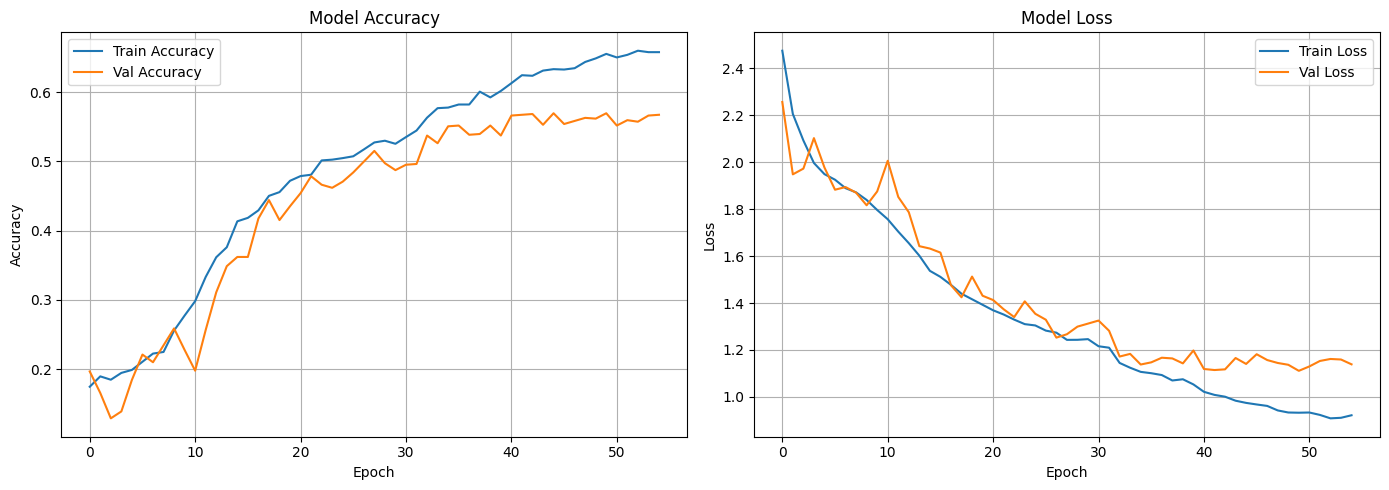

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'], label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history.history['loss'], label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Val Loss')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

## 9. Evaluate on Test Set

In [8]:
test_loss, test_acc = model.evaluate(test_ds)
print(f'\nTest Accuracy: {test_acc:.4f}')
print(f'Test Loss:     {test_loss:.4f}')

# Classification report
y_pred = model.predict(test_ds)
y_pred_labels = np.argmax(y_pred, axis=1)
y_true_labels = np.argmax(y_test, axis=1)

print('\nClassification Report:')
print(classification_report(y_true_labels, y_pred_labels, target_names=EMOTION_LABELS))

15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 118ms/step - accuracy: 0.5721 - loss: 1.1479

Test Accuracy: 0.5721
Test Loss:     1.1479
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 67ms/step

Classification Report:
              precision    recall  f1-score   support

       Angry       0.48      0.56      0.51       138
     Disgust       0.75      0.56      0.64        43
        Fear       0.41      0.26      0.32       123
       Happy       0.86      0.70      0.77       190
         Sad       0.45      0.42      0.43       139
    Surprise       0.76      0.72      0.74       110
     Neutral       0.47      0.71      0.56       159

    accuracy                           0.57       902
   macro avg       0.60      0.56      0.57       902
weighted avg       0.59      0.57      0.57       902



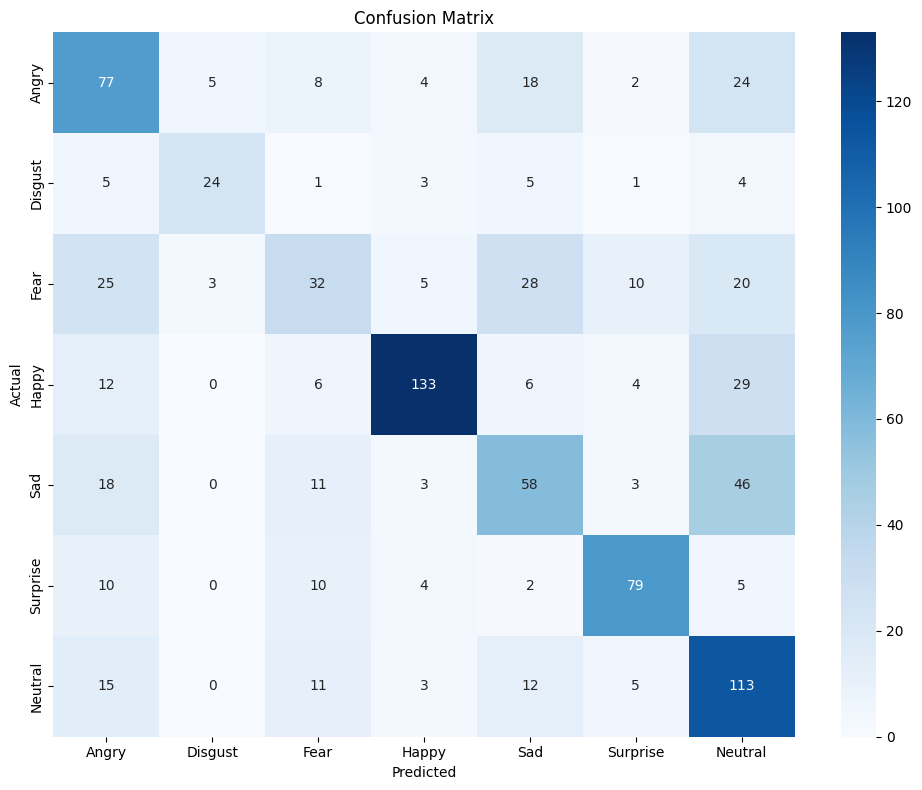

In [9]:
# Confusion matrix
cm = confusion_matrix(y_true_labels, y_pred_labels)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=EMOTION_LABELS, yticklabels=EMOTION_LABELS)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

## 10. Save & Download the Model

In [42]:
# Save final model
model.save('fer_model_final.keras')
print('Model saved!')

# # Download the best model
# files.download('best_fer_model.keras')

Model saved!


## 11. (Optional) Predict on a Single Image
Use this to test inference on one sample from the test set.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


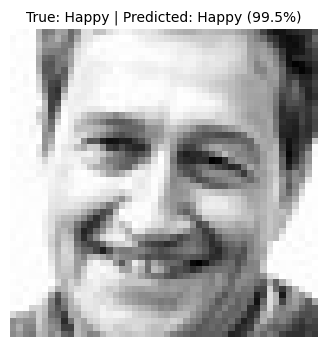

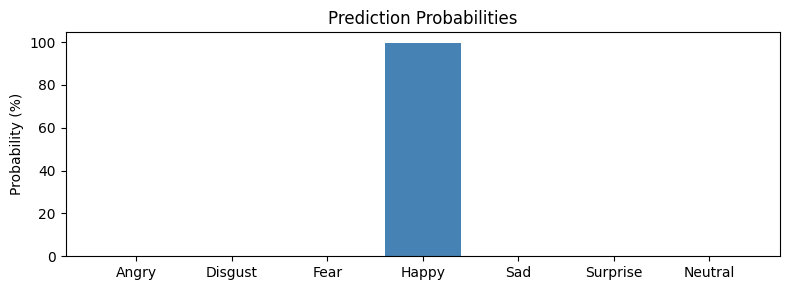

In [33]:
# Predict on a random test sample
idx = np.random.randint(0, len(X_test))
sample = X_test[idx]
true_label = EMOTION_LABELS[np.argmax(y_test[idx])]

pred = model.predict(sample[np.newaxis, ...])[0]
pred_label = EMOTION_LABELS[np.argmax(pred)]
confidence = np.max(pred) * 100

plt.figure(figsize=(4, 4))
plt.imshow(sample.squeeze(), cmap='gray')
plt.title(f'True: {true_label} | Predicted: {pred_label} ({confidence:.1f}%)', fontsize=10)
plt.axis('off')
plt.show()

# Show all class probabilities
plt.figure(figsize=(8, 3))
plt.bar(EMOTION_LABELS, pred * 100, color='steelblue')
plt.ylabel('Probability (%)')
plt.title('Prediction Probabilities')
plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


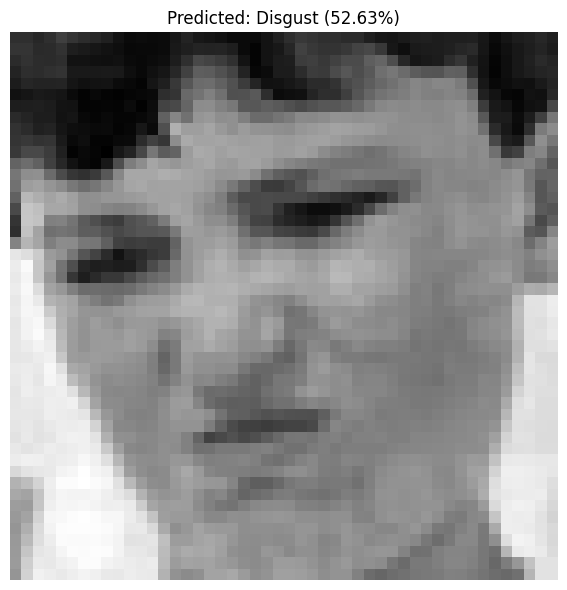

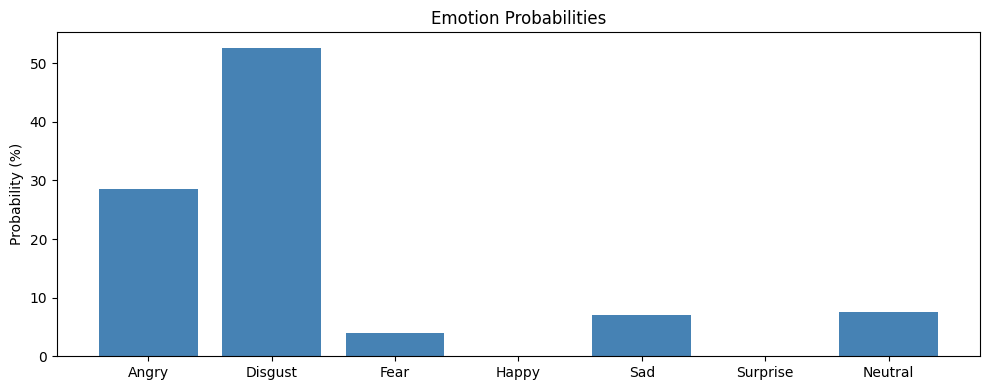

In [41]:
import cv2
from PIL import Image

# Load your own image
image_path = '../10018.jpg'  # Change this to your image path

# Read the image
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

# Resize to 48x48
img_resized = cv2.resize(img, (48, 48))

# Normalize to [0, 1]
img_normalized = img_resized.astype(np.float32) / 255.0

# Reshape for model input
img_input = img_normalized.reshape(1, 48, 48, 1)

# Make prediction
prediction = model.predict(img_input)
predicted_emotion = EMOTION_LABELS[np.argmax(prediction)]
confidence = np.max(prediction) * 100

# Display results
plt.figure(figsize=(6, 6))
plt.imshow(img_resized, cmap='gray')
plt.title(f'Predicted: {predicted_emotion} ({confidence:.2f}%)', fontsize=12)
plt.axis('off')
plt.tight_layout()
plt.show()

# Show all probabilities
plt.figure(figsize=(10, 4))
plt.bar(EMOTION_LABELS, prediction[0] * 100, color='steelblue')
plt.ylabel('Probability (%)')
plt.title('Emotion Probabilities')
plt.tight_layout()
plt.show()